### Playing with data
Aims of exploratory data anlysis, explore relationships between:
- Rainfall descriptors (event volume, is this the only rainfall characteristic?)
- Flooding outcomes ()
- Catchment descriptors
- Antecedent soil moisture conditions (mean value over catchment?, would there be a way to find mean value more specifically over the peak of the rainfall event )

In [1]:
# from jupyterthemes import get_themes
# import jupyterthemes as jt
# from jupyterthemes.stylefx import set_nb_theme

# set_nb_theme('monokai')

# jt -t monokai -N -T -kl

In [2]:
def mask_to_catchment(cube, catchment):

    catchment_proj = catchment.to_crs(epsg=27700)
    
    # Extract coordinates
    x = cube.coord('projection_x_coordinate').points
    y = cube.coord('projection_y_coordinate').points
    
    # Create 2D meshgrid of coordinates
    xx, yy = np.meshgrid(x, y)
    
    # Flatten coordinates
    points = np.vstack((xx.ravel(), yy.ravel())).T
    
    # Get catchment geometry
    catchment_geom = catchment_proj.geometry.iloc[0]
    
    # Test which grid cells are inside catchment
    mask = np.array([catchment_geom.contains(Point(pt)) for pt in points])
    
    # Reshape to grid
    mask = mask.reshape(len(y), len(x))
    return mask

def plot_soil_moisture_one_year_with_seasonal_boundaries(years, ax, one_plot, dataframe, col):
#     one_year_soil_moisture = dataframe[dataframe['year']==year]
    one_year_soil_moisture = daily_means[daily_means['year'].isin(years)]
#     one_year_events = rainfall_events[rainfall_events['start_year']==year].copy()
    
    ax.plot(one_year_soil_moisture['dates'], one_year_soil_moisture[col])
    
    # Axis labels
    if  ax.get_subplotspec().is_first_col() :
        ax.set_ylabel("Catchment Mean \n Soil Moisture")
    else:
        ax.set_ylabel("")

    if  ax.get_subplotspec().is_last_row() :
        ax.set_xlabel("Model Time")
    else:
        ax.set_xlabel("")
    
    # Title
    ax.set_title(year)
    
    #ax.xaxis.set_major_locator(mdates.MonthLocator())
    # Format tick labels to show month only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Jan, Feb, etc.
    plt.setp(ax.get_xticklabels(), rotation=0)
    if one_plot:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    
    # # Define season boundaries
#     winter_start = pd.Timestamp(f"{year}-01-01")
#     spring_start = pd.Timestamp(f"{year}-03-01")
#     summer_start = pd.Timestamp(f"{year}-06-01")
#     autumn_start = pd.Timestamp(f"{year}-09-01")
#     winter2_start = pd.Timestamp(f"{year}-12-01")
#     next_year_start = pd.Timestamp(f"{year+1}-01-01")

#     # # Add shaded regions
#     ax.axvspan(winter_start, spring_start, color='lightblue', alpha=0.2)
#     ax.axvspan(spring_start, summer_start, color='lightgreen', alpha=0.2)
#     ax.axvspan(summer_start, autumn_start, color='khaki', alpha=0.2)
#     ax.axvspan(autumn_start, winter2_start, color='navajowhite', alpha=0.2)
#     ax.axvspan(winter2_start, next_year_start, color='lightblue', alpha=0.2)

#     event_dates= one_year_events['start_date']
#     if len(event_dates) >0:
#         for event in event_dates:
#             try:
#                 ax.axvline(event, color = 'red', linestyle='--');
#             except:
#                 print("date which breaks rules")
                
def create_datetime_dates_from_cube(cube):
#     time_coord = cube.coord('time')
#     dates = time_coord.units.num2date(time_coord.points)
    time_numeric = cube.coord('time').points
    dates = pd.to_datetime("1970-01-01") + pd.to_timedelta(time_numeric, unit='h')
    return dates             

In [3]:
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import os
import numpy as np
import contextily as ctx
import iris
import iris.quickplot as qplt
import iris.plot as iplt
import iris.coord_categorisation
from shapely.geometry import Point
import glob
import cartopy.crs as ccrs
import pickle 
import cftime

home_dir = "C:/Users/kv25483/OneDrive - University of Bristol/FutureFlood/Data/"
home_dir = "/scratch/hydro4/users/" # kv25483/"

# Prepare the data
Get soil data for one ensemble member over UK (from 1980 to 2080), joined into one cube

In [4]:
# Get a list of all the filenames for this EM
filenames = []
for filename in glob.glob("/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_01/*"):
    filenames.append(filename)
# Convert to an iris cubelist
cube_list = iris.load(filenames)
# Concatenate into one cube
model_cube = cube_list.concatenate_cube()  

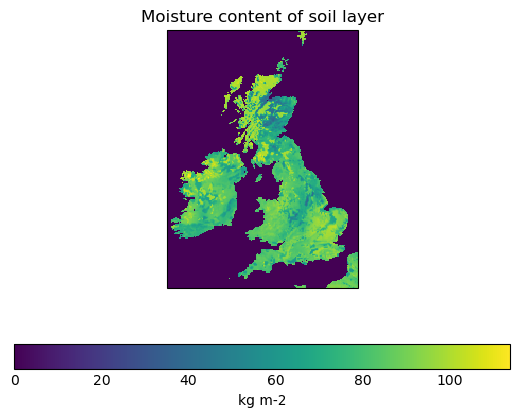

In [16]:
qplt.pcolormesh(model_cube[1,:,:])

Mask the data to the Newcastle catchment

In [4]:
## Get spatial extent of catchment
catchments = gpd.read_file(home_dir + "kv25483/FutureFlood/Data/NewcastleExample/catchment_identifier/hyd_areas_GB_with_subcatchments.shp")
newcastle = catchments[catchments['HA_NUM'] == "23"]

In [5]:
mask = mask_to_catchment(model_cube, newcastle)

Get the dates in human readable (and plottable) format

In [16]:
iris.FUTURE.date_microseconds = True
# Suppose your cube is called model_cube
time_coord = model_cube.coord('time')
cftime_dates = time_coord.units.num2date(time_coord.points)

# Function to convert a cftime object to string
def cft_to_string(cfttime_obj):
    """
    Convert a cftime.Datetime360Day (or other CFTime) object to 'YYYY-MM-DD' string
    """
    # Handle PartialDateTime or cftime
    try:
        year = str(cfttime_obj.year)
        month = str(cfttime_obj.month).zfill(2)
        day = str(cfttime_obj.day).zfill(2)
        return f"{year}-{month}-{day}"
    except AttributeError:
        return None  # in case it's missing or invalid

# Apply conversion
dates_as_strings = list(map(cft_to_string, cftime_dates))

# Convert to pandas datetime, coercing impossible dates to NaT
dates = pd.to_datetime(dates_as_strings, errors='coerce')

In [9]:
print(dates[:4])

years = dates.year
print(years[:4])

DatetimeIndex(['1980-12-01', '1980-12-02', '1980-12-03', '1980-12-04'], dtype='datetime64[ns]', freq=None)
Index([1980.0, 1980.0, 1980.0, 1980.0], dtype='float64')


## Find the mean daily/monthly soil moisture over time in Newcastle catchment

Find mean moisture over catchment (masking on the fly)

In [10]:
# The np.where condition means: Where grid cells are inside Newcastle → keep real soil moisture values
#                               Where grid cells outside Newcastle → replace with np.nan
# This creates (on the fly) a masked 3D array with shape: (nt, ny, nx), which isn't saved but is used in the np.nanmean() calculation
# np.nanmean() then calculates the mean value across ny, nx dimensions (i.e. across the catchment), ignoring any np.nan values 
# To produce an output of shape (,nt).
if os.path.exists('../Data/catchment_daily_mean.pickle'):
    print("File already exists, reading in")
    file = open('../Data/catchment_daily_mean.pickle','rb')
    catchment_daily_mean = pickle.load(file)
else:
    catchment_daily_mean = np.nanmean(np.where(mask, model_cube.data, np.nan), axis=(1, 2))
    with open('../Data/catchment_daily_mean.pickle', 'wb') as handle:
        pickle.dump(catchment_daily_mean, handle, protocol=pickle.HIGHEST_PROTOCOL)

File already exists, reading in


In [45]:
# model_cube.data has shape (time, y, x)
full_catchment_daily_mean = np.nanmean(model_cube.data, axis=(1, 2))


KeyboardInterrupt



Convert to dataframe

In [24]:
daily_means = pd.DataFrame({'dates':dates, 'daily_means':catchment_daily_mean, 'year':years})
daily_means = daily_means.dropna()

Convert to monthly mean (and recreate daily mean, as setting the index to 'dates' messes it up)

In [25]:
daily_means = daily_means.set_index('dates')
monthly_means = daily_means['daily_means'].resample('MS').mean()
monthly_means = (daily_means['daily_means'].resample('MS').mean().reset_index())
monthly_means.rename(columns={'daily_means':'monthly_means'}, inplace=True)
monthly_means['year'] = monthly_means['dates'].dt.year
monthly_means['month'] = monthly_means['dates'].dt.month
daily_means = pd.DataFrame({'dates':dates, 'daily_means':catchment_daily_mean, 'year':years})

## Get rainfall events

In [2]:
# os.listdir("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_varying")

In [3]:
# os.listdir("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_varying_95th")
rainfall_events =pd.read_csv("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_consistent/NorthEastEngland_Ens_06_2020-2040_full_events.csv")

Create a date object, NB this has to be created as a 360 day calendar because there are some month/day combinations that are invalid (e.g., 30th Feb)   
360 day calendar object doesn't work with plotting functionality.  

In [18]:
rainfall_events['start_date'] = [cftime.Datetime360Day(y, m, d, h)
                for y, m, d, h in zip(rainfall_events['start_year'], rainfall_events['start_month'], 
                                      rainfall_events['start_day'], rainfall_events['start_hour'])]
rainfall_events['stop_date'] = [cftime.Datetime360Day(y, m, d, h)
                for y, m, d, h in zip(rainfall_events['stop_year'], rainfall_events['stop_month'], 
                                      rainfall_events['stop_day'], rainfall_events['stop_hour'])]

## Plot catchment average soil moisture over time
For one year

In [59]:
years = [2022,2023]
one_year_soil_moisture = daily_means[daily_means['year'].isin(years)]

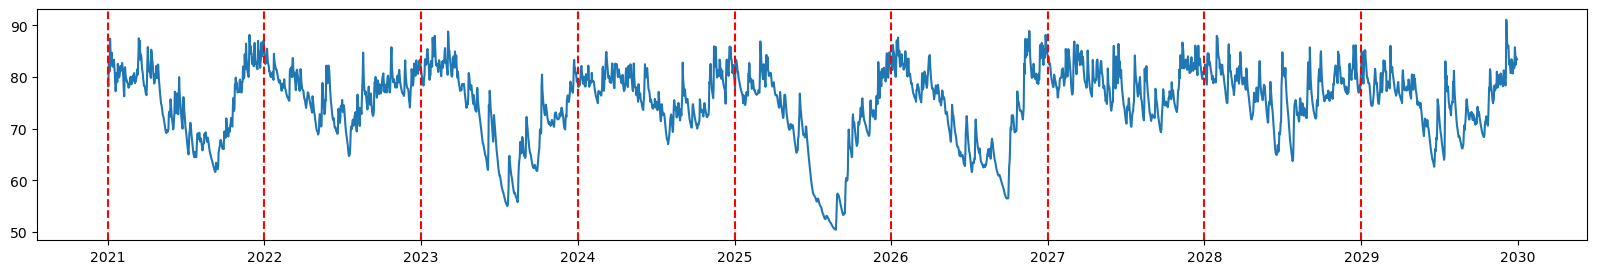

In [71]:
fig,ax=plt.subplots(figsize=(20,3))
years = [2021, 2022,2023,2024,2025,2026,2027,2028,2029]
one_year_soil_moisture = daily_means[daily_means['year'].isin(years)]
ax.plot(one_year_soil_moisture['dates'], one_year_soil_moisture['daily_means'])
for year in years:
    # Find the first date in that year
    start_of_year = one_year_soil_moisture.loc[one_year_soil_moisture['year'] == year, 'dates'].min()
    if pd.notna(start_of_year):
        ax.axvline(start_of_year, color='red', linestyle='--')

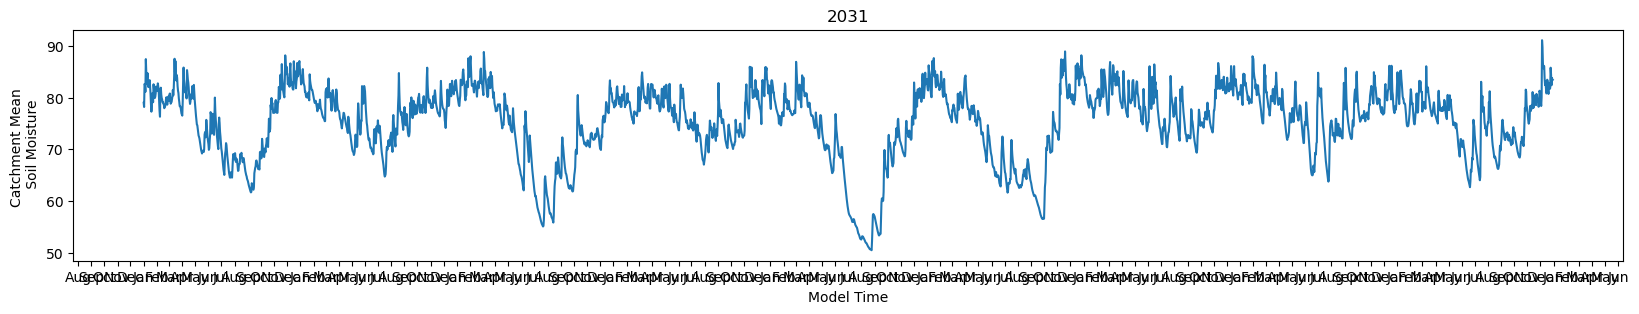

In [68]:
fig,ax=plt.subplots(figsize=(12,3))
plot_soil_moisture_one_year_with_seasonal_boundaries(year = 2022,2023, ax = ax, one_plot=True,
                                                    dataframe=daily_means, col='daily_means')

For multiple years

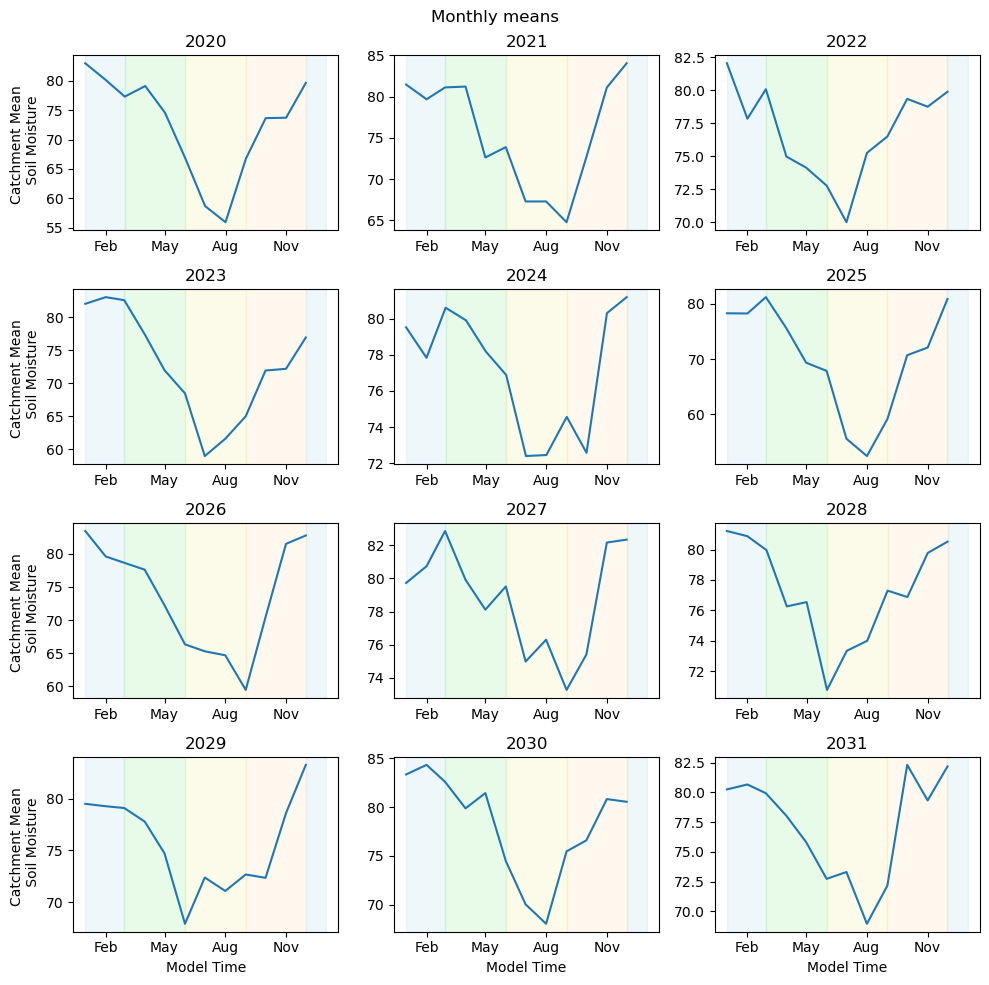

In [53]:
fig,axs=plt.subplots(ncols=3, nrows=4, figsize=(10,10), sharey=False)
axs=axs.flatten()
for ax_num, year in enumerate(range(2020,2032)):
    plot_soil_moisture_one_year_with_seasonal_boundaries(year = year, ax = axs[ax_num], one_plot=False,
                                                        dataframe=monthly_means, col = 'monthly_means')
fig.suptitle("Monthly means")
fig.tight_layout()

## Look more closely at soil moisture either side of events

Convert dates of rainfall events

In [20]:
# def convert_360day_to_datetime(year, month, day, origin_year=1970):
#     # Number of days since origin in 360-day calendar
#     years_since_origin = year - origin_year
#     total_days = (
#         years_since_origin * 360
#         + (month - 1) * 30
#         + (day - 1))
    
#     return pd.Timestamp("1970-01-01") + pd.Timedelta(days=total_days)

# rainfall_events['start_date_tinkered'] = [
#     convert_360day_to_datetime(y, m, d)
#     for y, m, d in zip(rainfall_events['start_year'],
#                        rainfall_events['start_month'],
#                        rainfall_events['start_day'])]

In [21]:
# rainfall_events['start_date'] = [cftime.Datetime360Day(y, m, d, h)
#                 for y, m, d, h in zip(events['start_year'], events['start_month'], events['start_day'], events['start_hour'])]

In [39]:
# Create a datetime column, coercing invalid dates to NaT
rainfall_events['start_date'] = pd.to_datetime(
    dict(year=rainfall_events['start_year'],month=rainfall_events['start_month'],
        day=rainfall_events['start_day'], hour =rainfall_events['start_hour']), errors='coerce')

rainfall_events['stop_date'] = pd.to_datetime(
    dict(year=rainfall_events['stop_year'],month=rainfall_events['stop_month'],
        day=rainfall_events['stop_day'], hour =rainfall_events['stop_hour']), errors='coerce')

# Inspect
print(rainfall_events[['start_year','start_month','start_day','start_date', 'start_hour']].head())

   start_year  start_month  start_day          start_date  start_hour
0        2020           12         11 2020-12-11 06:00:00           6
1        2020           12         26 2020-12-26 19:00:00          19
2        2021            1          6 2021-01-06 04:00:00           4
3        2021            2         23 2021-02-23 21:00:00          21
4        2021            2         27 2021-02-27 06:00:00           6


<!-- Not working because daily_means['dates'][0] is a Timestamp  
And start_window is cftime.Datetime360Day(2022, 1, 30, 20, 0, 0, 0, has_year_zero=True) -->

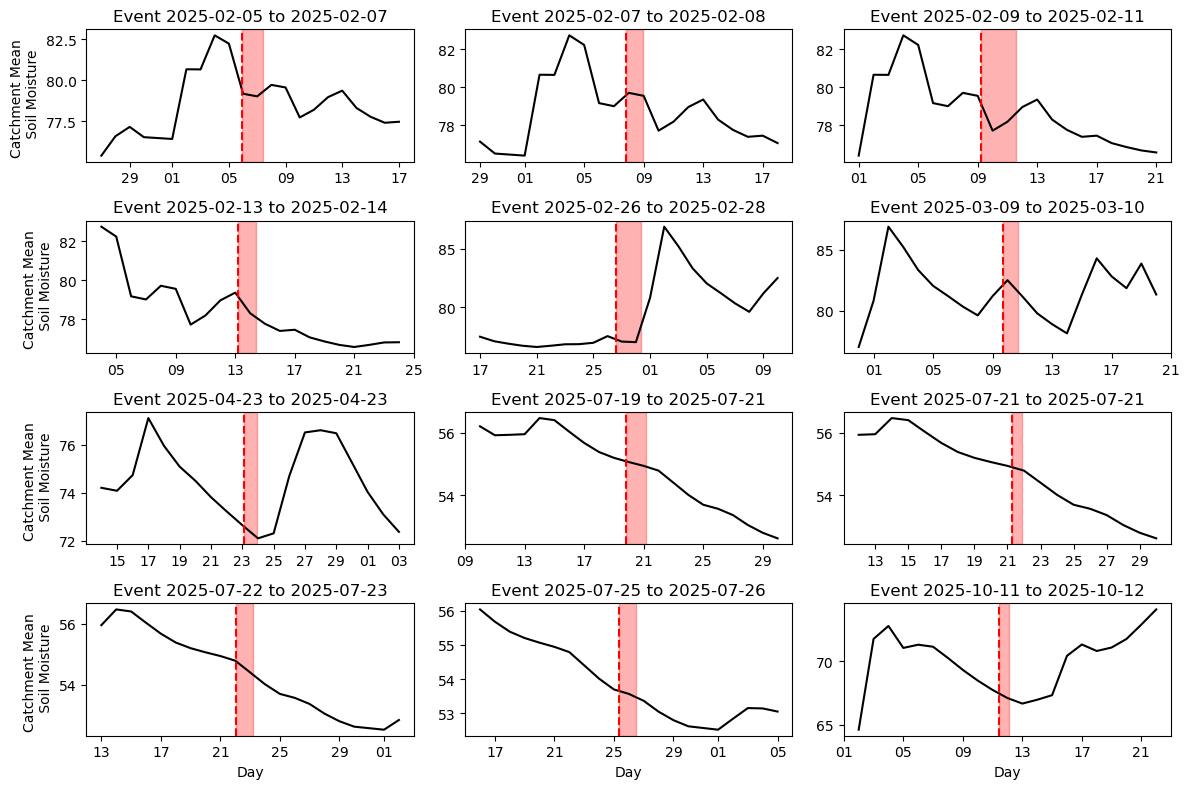

In [76]:
year = 2025

# Get events for that year
one_year_events = rainfall_events[rainfall_events['start_year'] == year].copy()[:12]

n_events = len(one_year_events)

if n_events == 0:
    print("No events in this year.")
else:
    
    fig, axes = plt.subplots(int(np.ceil(n_events/3)), 3, figsize=(12, 8), sharex=False, sharey=False)
    axes = axes.flatten()
    
    # If only one event, axes is not a list
    if n_events == 1:
        axes = [axes]
    
    for ax, (_, event_row) in zip(axes, one_year_events.iterrows()):
        
        event_start = event_row['start_date']
        event_end   = event_row['stop_date']
        
        # Define window: 10 days before start to 10 days after end
        start_window = event_start - pd.Timedelta(days=10)
        end_window   = event_end + pd.Timedelta(days=10)
        
        # Subset soil moisture
        window_data = daily_means[
            (daily_means['dates'] >= start_window) &
            (daily_means['dates'] <= end_window)]
        
        # Plot soil moisture
        ax.plot(window_data['dates'], window_data['daily_means'], color='black')
        
        # Shade event duration
        ax.axvspan(event_start, event_end, color='red', alpha=0.3)
        
        # Optional: vertical line at event start
        ax.axvline(event_start, color='red', linestyle='--')
        
        # Title
        ax.set_title(f"Event {event_start.date()} to {event_end.date()}")
        
        # Format x-axis
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
        plt.setp(ax.get_xticklabels(), rotation=0)
    
        # Format y-label only on first column
        if ax.get_subplotspec().is_first_col():
            ax.set_ylabel("Catchment Mean \n Soil Moisture")
        else:
            ax.set_ylabel("")

        # Format x-label only on last row
        if ax.get_subplotspec().is_last_row():
            ax.set_xlabel("Day")
        else:
            ax.set_xlabel("")

    # Hide any unused subplots
    for ax in axes[n_events:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()